In [4]:
import pandas as pd
import os
from google.colab import drive

In [5]:
drive.mount('/content/drive')
import os
image_folder = "/content/drive/MyDrive/captcha_images"
files = os.listdir(image_folder)
print("Total images:", len(files))
print("First 5:", files[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images: 2902
First 5: ['98LK.png', '9J8B.png', '9FQH.png', '8QW6.png', '9ATZ.png']


In [6]:
import cv2
images = []
for f in files:
    img_path = os.path.join(image_folder, f)
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)
print("Loaded", len(images), "images")

Loaded 2902 images


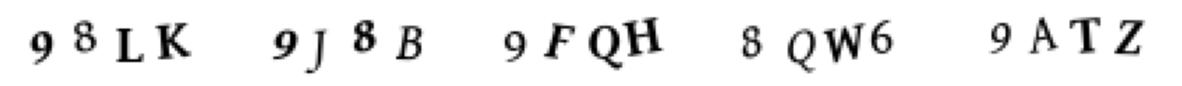

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.show()

CNN Model to detect text

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2
import string
import re

In [9]:
tf.random.set_seed(42)
np.random.seed(42)
IMG_HEIGHT = 64
IMG_WIDTH = 200
BATCH_SIZE = 32
EPOCHS = 50
MAX_TEXT_LENGTH = 20

In [10]:
characters = string.ascii_letters + string.digits + string.punctuation + ' '
num_chars = len(characters)

char_to_num = {char: idx for idx, char in enumerate(characters)}
num_to_char = {idx: char for idx, char in enumerate(characters)}

In [11]:
def preprocess_image(image_path):
    """Load and preprocess image"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

def encode_text(text):
    """Encode text to numerical format"""
    text = text.ljust(MAX_TEXT_LENGTH)[:MAX_TEXT_LENGTH]
    encoded = [char_to_num.get(char, char_to_num[' ']) for char in text]
    return np.array(encoded)

def decode_text(encoded_text):
    """Decode numerical text back to string"""
    text = ''.join([num_to_char.get(num, ' ') for num in encoded_text])
    return text.strip()

def load_dataset_from_filenames(data_dir):
    """Load dataset where filenames contain the text"""
    images = []
    texts = []

    # Supported image formats
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']

    for filename in os.listdir(data_dir):
        file_path = os.path.join(data_dir, filename)

        # Check if it's an image file
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            # Extract text from filename (remove extension)
            text = os.path.splitext(filename)[0]

            # Preprocess image
            img = preprocess_image(file_path)
            if img is not None:
                images.append(img)
                texts.append(encode_text(text))

    return np.array(images), np.array(texts)

def load_dataset_from_folders(data_dir):
    """Load dataset organized in folders (folder names are labels)"""
    images = []
    texts = []

    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']

    for folder_name in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder_name)

        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                file_path = os.path.join(folder_path, filename)

                if any(filename.lower().endswith(ext) for ext in image_extensions):
                    img = preprocess_image(file_path)
                    if img is not None:
                        images.append(img)
                        texts.append(encode_text(folder_name))

    return np.array(images), np.array(texts)

def create_cnn_model():
    """Create CNN model for text recognition"""
    model = keras.Sequential([
        # First CNN block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Second CNN block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Third CNN block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Fourth CNN block
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((1, 2)),

        # Flatten
        layers.Flatten(),

        # Dense layers
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(MAX_TEXT_LENGTH * num_chars, activation='softmax'),
        layers.Reshape((MAX_TEXT_LENGTH, num_chars))
    ])

    return model

def train_model(data_dir, dataset_type='filenames'):
    """Train the model"""
    print("Loading dataset...")

    if dataset_type == 'filenames':
        X, y = load_dataset_from_filenames(data_dir)
    elif dataset_type == 'folders':
        X, y = load_dataset_from_folders(data_dir)
    else:
        raise ValueError("dataset_type must be 'filenames' or 'folders'")

    if len(X) == 0:
        print("No data found! Please check your dataset path.")
        return None

    print(f"Dataset loaded: {X.shape[0]} samples")

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    print(f"Training samples: {X_train.shape[0]}")
    print(f"Validation samples: {X_val.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")

    # Data augmentation
    datagen = ImageDataGenerator(
        rotation_range=5,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.05,
        shear_range=0.05
    )

    # Create model
    print("Creating model...")
    model = create_cnn_model()

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
        keras.callbacks.ModelCheckpoint(
            'text_recognition_model.h5',
            save_best_only=True,
            monitor='val_loss'
        )
    ]

    # Train model
    print("Training model...")
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test accuracy: {test_acc:.4f}")

    # Plot training history
    plot_training_history(history)

    return model, X_test, y_test

def plot_training_history(history):
    """Plot training history"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

def test_model(model, X_test, y_test):
    """Test the trained model"""
    print("Testing model...")

    predictions = model.predict(X_test)
    predicted_texts = []

    for pred in predictions:
        char_indices = np.argmax(pred, axis=1)
        predicted_text = decode_text(char_indices)
        predicted_texts.append(predicted_text)

    true_texts = [decode_text(label) for label in y_test]

    # Calculate accuracy
    correct = 0
    for i, (true, pred) in enumerate(zip(true_texts, predicted_texts)):
        if true == pred:
            correct += 1
        else:
            print(f"Sample {i}: True: '{true}' | Predicted: '{pred}'")

    accuracy = correct / len(true_texts)
    print(f"\nOverall accuracy: {accuracy:.4f} ({correct}/{len(true_texts)})")

    return true_texts, predicted_texts

def predict_sentence(model, image_path):
    """Predict text from a single image"""
    img = preprocess_image(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return None

    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    char_indices = np.argmax(prediction[0], axis=1)
    predicted_text = decode_text(char_indices)

    return predicted_text

Loading dataset...
Dataset loaded: 2902 samples
Training samples: 1856
Validation samples: 465
Test samples: 581
Creating model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 21, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     5,243,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1900)           │       488,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 20, 95)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,252,780 (23.85 MB)

...

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9898 - loss: 0.0383 - val_accuracy: 0.9985 - val_loss: 0.0142 - learning_rate: 1.2500e-04
Epoch 38/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9903 - loss: 0.0366 - val_accuracy: 0.9962 - val_loss: 0.0224 - learning_rate: 1.2500e-04
Epoch 39/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9906 - loss: 0.0403 - val_accuracy: 0.9973 - val_loss: 0.0146 - learning_rate: 1.2500e-04
Epoch 40/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9913 - loss: 0.0351 - val_accuracy: 0.9967 - val_loss: 0.0178 - learning_rate: 1.2500e-04
Epoch 41/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9917 - loss: 0.0354 - val_accuracy: 0.9975 - val_loss: 0.0150 - learning_rate: 1.2500e-04
Epoch 42/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9911 - loss: 0.0356 - val_accuracy: 0.9974 - val_loss: 0.0160 - learning_rate: 1.2500e-04
Epoch 43/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9908 - los

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9910 - loss: 0.0349 - val_accuracy: 0.9990 - val_loss: 0.0100 - learning_rate: 6.2500e-05
Epoch 45/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9911 - loss: 0.0342 - val_accuracy: 0.9990 - val_loss: 0.0112 - learning_rate: 6.2500e-05
Epoch 46/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9913 - loss: 0.0338 - val_accuracy: 0.9969 - val_loss: 0.0210 - learning_rate: 6.2500e-05
Epoch 47/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9920 - loss: 0.0335

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9920 - loss: 0.0335 - val_accuracy: 0.9990 - val_loss: 0.0090 - learning_rate: 6.2500e-05
Epoch 48/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9919 - loss: 0.0312

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9919 - loss: 0.0311 - val_accuracy: 0.9992 - val_loss: 0.0086 - learning_rate: 6.2500e-05
Epoch 49/50
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9920 - loss: 0.0343

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9920 - loss: 0.0342 - val_accuracy: 0.9992 - val_loss: 0.0082 - learning_rate: 6.2500e-05
Epoch 50/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9917 - loss: 0.0318 - val_accuracy: 0.9653 - val_loss: 0.1187 - learning_rate: 6.2500e-05
Test accuracy: 0.9990


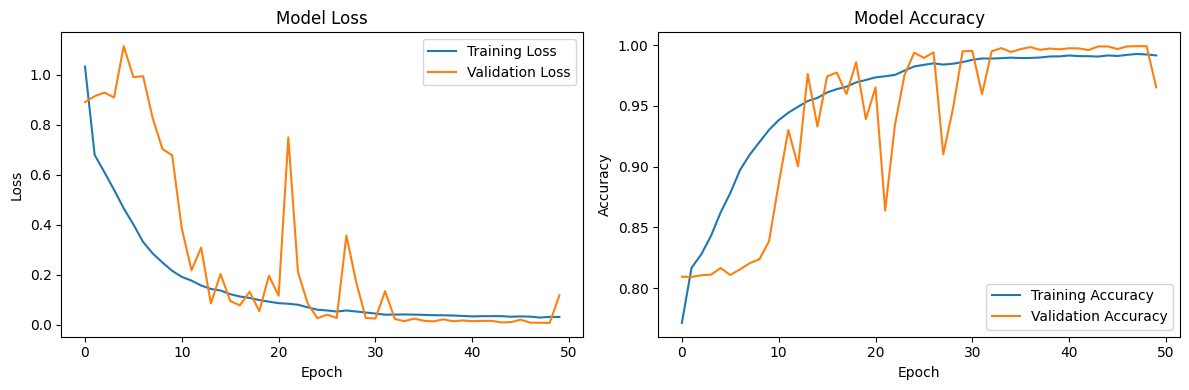

Testing model...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Sample 39: True: 'APFJ' | Predicted: 'ABFJ'
Sample 44: True: '2WP2' | Predicted: '2WB2'
Sample 85: True: '4ZV8' | Predicted: '42V8'
Sample 103: True: '6VYA' | Predicted: '6VY4'
Sample 172: True: '6WMT' | Predicted: '6WMF'
Sample 316: True: '26GM' | Predicted: '26KM'
Sample 328: True: '3SMX' | Predicted: '3SMR'
Sample 332: True: '2SEN' | Predicted: '2SEM'
Sample 409: True: '2VH3' | Predicted: '2YH3'
Sample 448: True: '2JPH' | Predicted: '2JFH'
Sample 517: True: '3P4D' | Predicted: '3R4D'
Sample 560: True: '4WWU' | Predicted: '4WNU'

Overall accuracy: 0.9793 (569/581)


In [12]:
data_dir = image_folder
dataset_type = 'filenames'
# Train the model
trained_model, X_test, y_test = train_model(data_dir, dataset_type)
# Test the model
true_texts, predicted_texts = test_model(trained_model, X_test, y_test)

In [13]:
# Save the trained model
if trained_model:
    trained_model.save('final_text_recognition_model.h5')
    print("Model saved as final_text_recognition_model.h5")

Model saved as final_text_recognition_model.h5


Add Distortions using GAN

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

In [6]:
def load_images_from_folder(folder_path, img_size=(64,128), max_images=100):
    images = []
    filenames = []
    files = os.listdir(folder_path)[:max_images]
    for file in files:
        img_path = os.path.join(folder_path, file)
        img = load_img(img_path, target_size=img_size, color_mode='grayscale')
        img = img_to_array(img) / 255.0
        images.append(img)
        filenames.append(file)  # Keep original filenames
    return np.array(images), filenames

In [7]:
folder_path = image_folder
X_train, filenames = load_images_from_folder(folder_path, img_size=(64,128), max_images=100)
print(f"Loaded {len(X_train)} images")

Loaded 100 images


In [8]:
def build_generator(latent_dim=100, img_shape=(64,128,1)):
    model = models.Sequential()
    model.add(layers.Dense(16*32*256, input_dim=latent_dim))
    model.add(layers.Reshape((16, 32, 256)))
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same', activation='relu'))
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=1, padding='same', activation='sigmoid'))
    return model

In [9]:
def build_discriminator(img_shape=(64,128,1)):
    model = models.Sequential()
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=img_shape))
    model.add(layers.ReLU())
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(layers.ReLU())
    model.add(layers.Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(layers.ReLU())
    model.add(layers.Conv2D(512, kernel_size=4, strides=2, padding='same'))
    model.add(layers.ReLU())
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [10]:
latent_dim = 100
img_shape = (64,128,1)

generator = build_generator(latent_dim, img_shape)
discriminator = build_discriminator(img_shape)

discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.trainable = False

gan_input = layers.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = models.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
def distort_images(images):
    distorted = []
    for img in images:
        img = tf.image.random_brightness(img, 0.07)
        img = tf.image.random_contrast(img, 0.98, 1.001)
        distorted.append(img.numpy())
    return np.array(distorted)

In [36]:
def train_gan(generator, discriminator, gan, X_train, epochs=100, batch_size=16):
    valid = np.ones((batch_size,1))
    fake = np.zeros((batch_size,1))

    for epoch in range(epochs):
        # -----------------
        # Train Discriminator
        # -----------------
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_imgs = X_train[idx]
        real_imgs = distort_images(real_imgs)

        noise = np.random.normal(0,1,(batch_size, latent_dim))
        gen_imgs = generator.predict(noise, verbose=0)

        discriminator.train_on_batch(real_imgs, valid)
        discriminator.train_on_batch(gen_imgs, fake)

        # -----------------
        # Train Generator
        # -----------------
        noise = np.random.normal(0,1,(batch_size, latent_dim))
        gan.train_on_batch(noise, valid)

In [37]:
def save_distorted_images(X_train, filenames, save_folder="contents"):
    os.makedirs(save_folder, exist_ok=True)
    distorted = distort_images(X_train)
    for i, img in enumerate(distorted):
        img_to_save = (img * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_to_save[:,:,0])
        img_pil.save(os.path.join(save_folder, filenames[i]))
    print(f"Saved {len(filenames)} distorted images in '{save_folder}'")

In [44]:
train_gan(generator, discriminator, gan, X_train, epochs=100, batch_size=16)
save_distorted_images(X_train, filenames, save_folder="contents")

Saved 100 distorted images in 'contents'


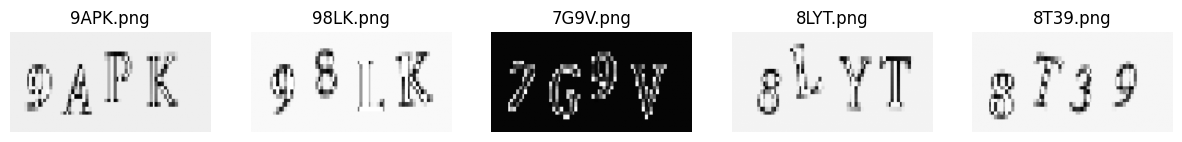

In [45]:
import matplotlib.pyplot as plt
import os
import cv2

save_folder = "contents"
distorted_files = os.listdir(save_folder)

# Display the first 5 distorted images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    if i < len(distorted_files):
        img_path = os.path.join(save_folder, distorted_files[i])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(distorted_files[i])
        ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots
plt.show()

Loading dataset...
Dataset loaded: 100 samples
Training samples: 64
Validation samples: 16
Test samples: 20
Creating model...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 62, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 29, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 21, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 4, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     5,243,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1900)           │       488,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 20, 95)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,252,780 (23.85 MB)

 Trainable params: 6,251,820 (23.85 MB)

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8391 - loss: 0.6874 - val_accuracy: 0.8344 - val_loss: 1.0976 - learning_rate: 0.0010
Epoch 11/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8359 - loss: 0.6819

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8385 - loss: 0.6658 - val_accuracy: 0.8344 - val_loss: 0.8616 - learning_rate: 0.0010
Epoch 12/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8453 - loss: 0.6027

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8401 - loss: 0.6199 - val_accuracy: 0.8344 - val_loss: 0.7439 - learning_rate: 0.0010
Epoch 13/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8328 - loss: 0.6193

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8354 - loss: 0.6149 - val_accuracy: 0.8219 - val_loss: 0.6846 - learning_rate: 0.0010
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8398 - loss: 0.5862 

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.8396 - loss: 0.5824 - val_accuracy: 0.8188 - val_loss: 0.6642 - learning_rate: 0.0010
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8422 - loss: 0.5941 - val_accuracy: 0.8188 - val_loss: 0.6659 - learning_rate: 0.0010
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8406 - loss: 0.6010 - val_accuracy: 0.8219 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 17/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8583 - loss: 0.5283 - val_accuracy: 0.8250 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 18/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8469 - loss: 0.5229 - val_accuracy: 0.8344 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 19/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8557 - loss: 0.5213 - val_accuracy: 0.8313 - val_loss: 0.6893 - learning_rate: 0.0010
Epoch 20/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8630 - loss: 0.4680 - val_accuracy: 0.8313 

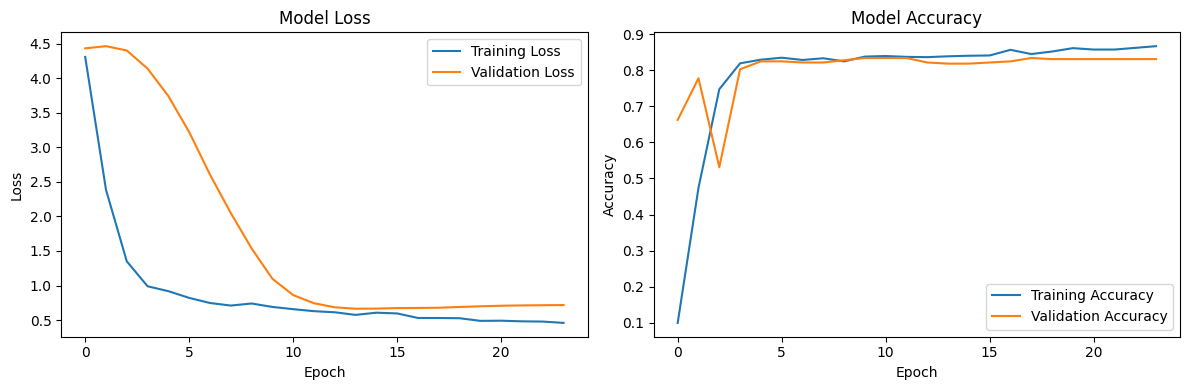

Testing model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
Sample 0: True: '887X' | Predicted: '7VEQ'
Sample 1: True: '7DKQ' | Predicted: '7VEQ'
Sample 2: True: '7Y9L' | Predicted: '7V27'
Sample 3: True: '8F8F' | Predicted: '7VEQ'
Sample 4: True: '6Z3P' | Predicted: '7V27'
Sample 5: True: '7PLU' | Predicted: '7VEQ'
Sample 6: True: '9EWC' | Predicted: '7VEQ'
Sample 7: True: '8G9P' | Predicted: '7VEQ'
Sample 8: True: '8CW7' | Predicted: '7VEQ'
Sample 9: True: '9APK' | Predicted: '7VEQ'
Sample 10: True: '7KXU' | Predicted: '7V27'
Sample 11: True: '9GBM' | Predicted: '7VEQ'
Sample 12: True: '7J7U' | Predicted: '7V27'
Sample 13: True: '8X2E' | Predicted: '7VEQ'
Sample 14: True: '9GNS' | Predicted: '7VEQ'
Sample 15: True: '8T39' | Predicted: '7VEQ'
Sample 16: True: '7NWW' | Predicted: '7V27'
Sample 17: True: '8T3A' | Predicted: '7VEQ'
Sample 18: True: '7FYA' | Predicted: '7VEQ'
Sample 19: True: '7TRK' | Predicted: '7VE7'

Overall accuracy: 0.0000 (0/20)


In [46]:
data_dir = "/content/contents"
dataset_type = 'filenames'
# Train the model
trained_model, X_test, y_test = train_model(data_dir, dataset_type)
# Test the model
true_texts, predicted_texts = test_model(trained_model, X_test, y_test)

In [47]:
import os
import random
from PIL import Image, ImageDraw

def add_horizontal_lines_to_folder(input_folder='contents',
                                   output_folder='contents/lines',
                                   line_color=(255, 0, 0),
                                   thickness=1):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_folder, filename)
            img = Image.open(img_path).convert('RGB')
            draw = ImageDraw.Draw(img)

            width, height = img.size
            num_lines = random.randint(8, 12)  # Number of horizontal lines

            for i in range(num_lines):
                y = int(i * height / num_lines + random.randint(-2, 2))
                draw.line([(0, y), (width, y)], fill=line_color, width=thickness)

            save_path = os.path.join(output_folder, filename)
            img.save(save_path)

    print(f"Lines added successfully! Saved in: {output_folder}")

# Example usage in Colab:
add_horizontal_lines_to_folder('contents', 'contents/lines')


Lines added successfully! Saved in: contents/lines


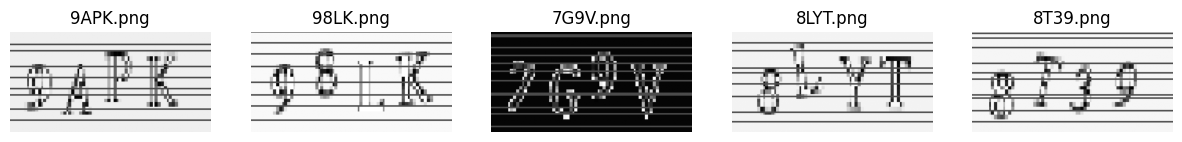

In [49]:
import matplotlib.pyplot as plt
import os
import cv2

save_folder = "contents/lines"
distorted_files = os.listdir(save_folder)

# Display the first 5 distorted images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    if i < len(distorted_files):
        img_path = os.path.join(save_folder, distorted_files[i])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(distorted_files[i])
        ax.axis('off')
    else:
        ax.axis('off') # Hide empty subplots
plt.show()

Loading dataset...
Dataset loaded: 100 samples
Training samples: 64
Validation samples: 16
Test samples: 20
Creating model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 62, 198, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 62, 198, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 29, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 29, 97, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 46, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 23, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 4, 21, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 4, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 10, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     5,243,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1900)           │       488,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 20, 95)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,252,780 (23.85 MB)

 Trainable params: 6,251,820 (23.85 MB)

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.8266 - loss: 0.6826 - val_accuracy: 0.8125 - val_loss: 0.9459 - learning_rate: 0.0010
Epoch 14/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8344 - loss: 0.6690

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step - accuracy: 0.8328 - loss: 0.6595 - val_accuracy: 0.8156 - val_loss: 0.7915 - learning_rate: 0.0010
Epoch 15/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8578 - loss: 0.5777

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8500 - loss: 0.5935 - val_accuracy: 0.8156 - val_loss: 0.7112 - learning_rate: 0.0010
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8344 - loss: 0.6501 

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.8354 - loss: 0.6446 - val_accuracy: 0.8125 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 17/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8441 - loss: 0.5902 

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.8438 - loss: 0.5926 - val_accuracy: 0.8125 - val_loss: 0.6784 - learning_rate: 0.0010
Epoch 18/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8406 - loss: 0.6346 - val_accuracy: 0.8125 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 19/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8401 - loss: 0.5769 - val_accuracy: 0.8094 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 20/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8505 - loss: 0.5461 - val_accuracy: 0.8125 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 21/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8458 - loss: 0.5494 - val_accuracy: 0.8250 - val_loss: 0.7012 - learning_rate: 0.0010
Epoch 22/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8443 - loss: 0.5317 - val_accuracy: 0.8250 - val_loss: 0.7049 - learning_rate: 0.0010
Epoch 23/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8562 - loss: 0.5189 - val_accuracy: 0.8250

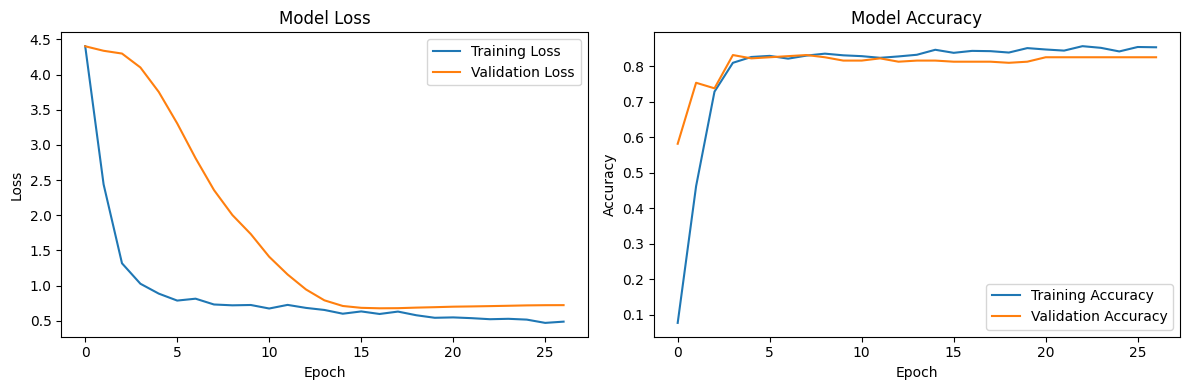

Testing model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Sample 0: True: '887X' | Predicted: '7B8B'
Sample 1: True: '7DKQ' | Predicted: '7B8B'
Sample 2: True: '7Y9L' | Predicted: '7B8B'
Sample 3: True: '8F8F' | Predicted: '7B8B'
Sample 4: True: '6Z3P' | Predicted: '7B8B'
Sample 5: True: '7PLU' | Predicted: '7B8B'
Sample 6: True: '9EWC' | Predicted: '7B8B'
Sample 7: True: '8G9P' | Predicted: '7B8B'
Sample 8: True: '8CW7' | Predicted: '7B8B'
Sample 9: True: '9APK' | Predicted: '7B8B'
Sample 10: True: '7KXU' | Predicted: '7B8B'
Sample 11: True: '9GBM' | Predicted: '7B8B'
Sample 12: True: '7J7U' | Predicted: '7B8B'
Sample 13: True: '8X2E' | Predicted: '7B8B'
Sample 14: True: '9GNS' | Predicted: '7B8B'
Sample 15: True: '8T39' | Predicted: '7B8B'
Sample 16: True: '7NWW' | Predicted: '7B8B'
Sample 17: True: '8T3A' | Predicted: '7B8B'
Sample 18: True: '7FYA' | Predicted: '7B8B'
Sample 19: True: '7TRK' | Predicted: '7B8B'

Overall accuracy: 0.0000 (0/20)


In [50]:
data_dir = "/content/contents/lines"
dataset_type = 'filenames'
# Train the model
trained_model, X_test, y_test = train_model(data_dir, dataset_type)
# Test the model
true_texts, predicted_texts = test_model(trained_model, X_test, y_test)

In [52]:
import os
import zipfile
from google.colab import files

def contents_as_zip(folder_path='contents/lines', zip_name='contents_folder.zip'):
    zip_path = f'/content/{zip_name}'

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_path))
                zipf.write(file_path, arcname)


contents_as_zip()